## *Example 1     $\hspace{10mm} \displaystyle \frac{dv}{dt} = 1 - v^2$*

Here we will only look at one variable, the velocity $v$ (we could solve for $v$ and position $x$, but will do that in Example 2).

y_sol = [[0.         0.29139548 0.53724021 0.7162084  0.83292152 0.90498676
  0.9468008  0.97042136 0.98372022 0.99097211 0.99500995]]

type(t_sol) = <class 'numpy.ndarray'>
type(y_sol) = <class 'numpy.ndarray'>
y_sol.shape = (1, 11)


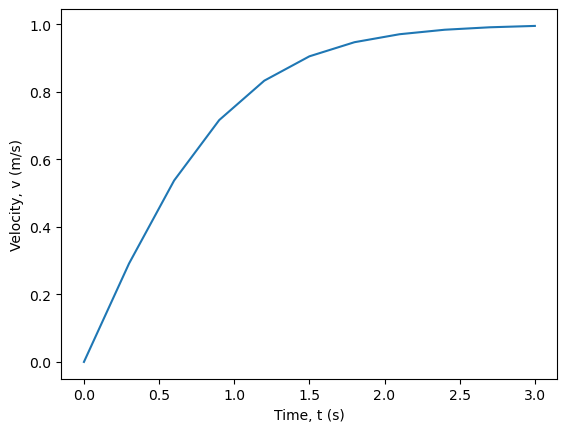

In [5]:
from scipy import integrate
import matplotlib.pyplot as plt
import numpy as np


def dydt_arr(t, y_arr):
    """
    This returns dv/dt as an array, even when there 
    is only one variable, y0, like in this case
    """
    v = y_arr[0]  # Velocity (y0), the first and only element in y_arr
    return np.array([1.0 - v**2])


v0 = 0.0  # Initial condition v(t=0)
y0_arr = np.array([v0])  # array for dydt_arr initial condition
t0 = 0.0  # initial time
tmax = 3.0  # maximum time
steps = 10  # number of time steps
dt = (tmax - t0) / steps  # size of the time step

# Create the 1d array for time values
t_arr = t0 + np.arange(steps + 1) * dt

# t_eval = t_arr specifies the times at which we'd like to see the solutions
sol = integrate.solve_ivp(dydt_arr, (t_arr[0], t_arr[-1]),
                          y0_arr,
                          t_eval=t_arr,
                          method='LSODA')

t_sol = sol['t']
y_sol = sol['y']

print('y_sol =', y_sol)

# The data types used in the code
print('\ntype(t_sol) =', type(t_sol))
print('type(y_sol) =', type(y_sol))
print('y_sol.shape =', y_sol.shape)

# Let's also plot ysol_arr[0,:] (velocity) as a function of t_arr (time)
plt.plot(t_sol, y_sol[0, :])
plt.xlabel('Time, t (s)')
plt.ylabel('Velocity, v (m/s)')
plt.show()

## *Example 2 $\hspace{10mm} \displaystyle m \frac{dv}{dt} = -kx - cv$*

For this example we are interested in two variables, position $x$, and velocity $v$, so we have two physical quantities, $y_0$ and $y_1$, respectively. The single 2nd-order differential equation is broken into two 1st-order equations since $dx/dt = v$. In this equation $m$ is the mass, $k$ is the spring constant and $c$ the damping constant. We'll set $k = m = 1$ for simplicity and $c = 0.1$. The code is:

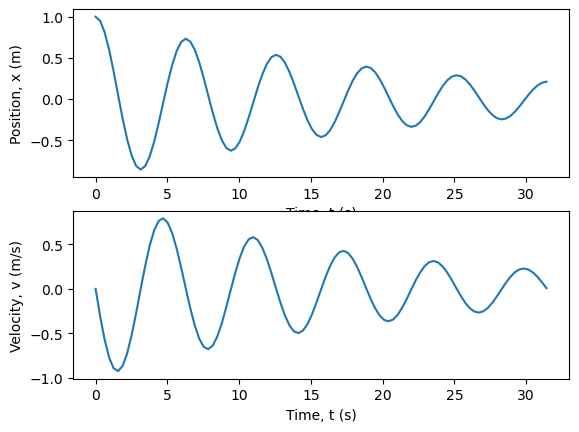

In [6]:
def dydt_arr(t, y_arr):
    x = y_arr[0]  # Position (1st element of y_arr)
    v = y_arr[1]  # Velocity (2dn element of y_arr)
    return np.array([v, -x - c * v])  # This is [dx/dt, dv/dt]


c = 0.1  # damping constant
t0 = 0.0
tmax = 10.0 * np.pi  # final time
steps = 100

t_arr = np.linspace(t0, tmax, steps + 1)  # 1d time array

# Initial condition for position, velocity
y0_arr = [1.0, 0.0]

# Solve the differential equation:
sol = integrate.solve_ivp(dydt_arr, (t_arr[0], t_arr[-1]),
                          y0_arr,
                          t_eval=t_arr,
                          method='LSODA')

t_sol = sol['t']
y_sol = sol['y']

# Let's also plot ysol_arr[0,:] (velocity) as a function of t_arr (time)
plt.subplot(211)  # Two rows, one column, top plot
plt.plot(t_sol, y_sol[0, :])
plt.xlabel('Time, t (s)')
plt.ylabel('Position, x (m)')

plt.subplot(212)  # Two rows, one column, bottom plot
plt.plot(t_sol, y_sol[1, :])
plt.xlabel('Time, t (s)')
plt.ylabel('Velocity, v (m/s)')

plt.show()

Experiment with different values of `c` to see how the results change. Also, spend some time playing around with these examples before you get started with the project to help you make sure you undertand how to use `solve_ivp`. As the problems become more complicated---such as with nonlinear terms or coupled systems---other techniques might be better, such as Green's function approach or Fourier transform. However, these are beyond the cope of PHYS221, so you can look forward to encountering those in the guture.